# **Random Forest(RF) on IoT Combined Dataset**

****Importing libraries****

In [2]:
import timeit
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import warnings
%matplotlib inline
warnings.filterwarnings('ignore')
#warnings.filterwarnings('always')

**Upload File**

In [3]:
#uploaded = files.upload()

**Importing the Dataset**

In [4]:
from google.colab import files
uploaded = files.upload()
import pandas as pd

import io

dataset = pd.read_csv(io.BytesIO(uploaded['Processed_Combined_IoT_dataset.csv']))

Saving Processed_Combined_IoT_dataset.csv to Processed_Combined_IoT_dataset.csv


**Exploratory Data Analysis**

In [5]:
dataset.head()

,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,current_temperature,door_state,fridge_temperature,humidity,latitude,light_status,longitude,motion_status,pressure,sphone_signal,temp_condition,temperature,thermostat_status,label
0,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.930769,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.2,0.517307,1,0
1,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.588462,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.2,0.517307,1,0
2,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.076923,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.8,0.517307,1,0
3,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.292308,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.8,0.517307,1,0
4,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.746154,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.2,0.517307,1,0


In [6]:
print(dataset.shape)

(401119, 18)


In [7]:
print(list(dataset.columns))

['FC1_Read_Input_Register', 'FC2_Read_Discrete_Value', 'FC3_Read_Holding_Register', 'FC4_Read_Coil', 'current_temperature', 'door_state', 'fridge_temperature', 'humidity', 'latitude', 'light_status', 'longitude', 'motion_status', 'pressure', 'sphone_signal', 'temp_condition', 'temperature', 'thermostat_status', 'label']


In [8]:
target_cols=list(dataset.columns[-1:])
target_cols

['label']

In [9]:
feature_cols= list(dataset.columns[:-1])
feature_cols

['FC1_Read_Input_Register',
 'FC2_Read_Discrete_Value',
 'FC3_Read_Holding_Register',
 'FC4_Read_Coil',
 'current_temperature',
 'door_state',
 'fridge_temperature',
 'humidity',
 'latitude',
 'light_status',
 'longitude',
 'motion_status',
 'pressure',
 'sphone_signal',
 'temp_condition',
 'temperature',
 'thermostat_status']

**Split Dataset**

In [10]:
#split dataset in features and target variable
X = dataset.drop('label', axis=1) # Features
y = dataset['label'] # Target variable

In [11]:
X.head()

,FC1_Read_Input_Register,FC2_Read_Discrete_Value,FC3_Read_Holding_Register,FC4_Read_Coil,current_temperature,door_state,fridge_temperature,humidity,latitude,light_status,longitude,motion_status,pressure,sphone_signal,temp_condition,temperature,thermostat_status
0,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.930769,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.2,0.517307,1
1,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.588462,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.2,0.517307,1
2,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.076923,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.8,0.517307,1
3,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.292308,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.8,0.517307,1
4,0.495216,0.499092,0.488897,0.499405,0.344399,0,0.746154,0.462511,0.008217,0,0.008112,0,0.533556,0.666667,0.2,0.517307,1


In [12]:
y.head()

,label
0,0
1,0
2,0
3,0
4,0


**Splitting Data**

In [13]:
# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test

In [14]:
# Check the shape of all of these
print("X_train shape is : ", X_train.shape)
print("X_test shape  is : ", X_test.shape)
print("y_train shape is : ", y_train.shape)
print("y_test shape is  : ", y_test.shape)

X_train shape is :  (280783, 17)
X_test shape  is :  (120336, 17)
y_train shape is :  (280783,)
y_test shape is  :  (120336,)


**Building Model**

In [15]:
#Calculate start time
start = timeit.default_timer()

#Create a Gaussian Classifier
clf=RandomForestClassifier(n_estimators=100)

#Train the model using the training sets y_pred=clf.predict(X_test)
clf.fit(X_train,y_train)

#Calculate Stop time
stop = timeit.default_timer()
train_time= stop - start

In [16]:
#Calculate start time
start = timeit.default_timer()

# Predict the model
y_pred=clf.predict(X_test)

#Calculate Stop time
stop = timeit.default_timer()
test_time= stop - start

**Evaluating Model**

In [17]:
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

[[69924  3571]
 [12083 34758]]
              precision    recall  f1-score   support

           0       0.85      0.95      0.90     73495
           1       0.91      0.74      0.82     46841

    accuracy                           0.87    120336
   macro avg       0.88      0.85      0.86    120336
weighted avg       0.87      0.87      0.87    120336



In [18]:
# Model Accuracy: how often is the classifier correct?
print("Accuracy:",metrics.accuracy_score(y_test, y_pred))

# Model Precision: what percentage of positive tuples are labeled as such?
print("Precision:",metrics.precision_score(y_test, y_pred))

# Model Recall: what percentage of positive tuples are labelled as such?
print("Recall:",metrics.recall_score(y_test, y_pred))

#Calculate F1 Score
print("F1 Score:",metrics.f1_score(y_test, y_pred))

#Calculate Mean Absolute Error
print("Mean Absolute Error:",metrics.mean_absolute_error(y_test, y_pred))

# kappa
print("Cohens kappa:", metrics.cohen_kappa_score(y_test, y_pred))

# ROC AUC
print("ROC AUC:", metrics.roc_auc_score(y_test, y_pred))

#Train time
print('Train Time(s): ',train_time)

#Test time
print('Test Time(s): ',test_time)

Accuracy: 0.8699142401276426
Precision: 0.9068329463330638
Recall: 0.7420422279626823
F1 Score: 0.8162028883409651
Mean Absolute Error: 0.1300857598723574
Cohens kappa: 0.7170831180135777
ROC AUC: 0.8467269443099348
Train Time(s):  91.17639331399982
Test Time(s):  4.178288665000082


In [19]:
# Additional algorithms for the Processed Combined IoT dataset

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
    classification_report
)

# Check the available class labels in the IoT dataset
iot_class_labels = sorted(y.unique())

print("IoT class labels:")
print(iot_class_labels)

# Define the classification algorithms
iot_models = {
    "Decision Tree": DecisionTreeClassifier(random_state=17),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=17),
    "K-Nearest Neighbours": make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=5)),
    "Naive Bayes": GaussianNB(),
    "Logistic Regression": make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=17)),
    "Support Vector Machine": make_pipeline(StandardScaler(), LinearSVC(random_state=17, max_iter=5000))
}

print("IoT models are ready:")
for name in iot_models.keys():
    print("-", name)

IoT class labels:
[np.int64(0), np.int64(1)]
IoT models are ready:
- Decision Tree
- Random Forest
- K-Nearest Neighbours
- Naive Bayes
- Logistic Regression
- Support Vector Machine


In [20]:
# Train and evaluate each algorithm on the Processed Combined IoT dataset

iot_all_results = {}
iot_summary_results = []

for model_name, model in iot_models.items():
    print("=" * 80)
    print("Algorithm:", model_name)
    print("=" * 80)

    # Train the model
    model.fit(X_train, y_train)

    # Predict on the test dataset
    y_pred = model.predict(X_test)

    # Confusion matrix
    cm = confusion_matrix(y_test, y_pred, labels=iot_class_labels)
    print("Confusion Matrix:")
    print(cm)

    # Precision, Recall, F1-score for each class
    precision, recall, f1, support = precision_recall_fscore_support(
        y_test,
        y_pred,
        labels=iot_class_labels,
        zero_division=0
    )

    # Calculate False Positive Rate for each class
    fpr_list = []
    for i, label in enumerate(iot_class_labels):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = cm.sum() - (TP + FP + FN)

        fpr = FP / (FP + TN) if (FP + TN) != 0 else 0
        fpr_list.append(fpr)

    # Create class-level table
    class_table = pd.DataFrame({
        "Class": iot_class_labels,
        "Precision (%)": precision * 100,
        "Recall (%)": recall * 100,
        "F1-Score (%)": f1 * 100,
        "False Alarm / FPR (%)": np.array(fpr_list) * 100,
        "Support": support
    })

    display(class_table)

    # Overall measures
    accuracy = accuracy_score(y_test, y_pred)
    avg_precision = np.mean(precision)
    avg_recall = np.mean(recall)
    avg_f1 = np.mean(f1)
    avg_fpr = np.mean(fpr_list)

    iot_summary_results.append({
        "Algorithm": model_name,
        "Accuracy (%)": accuracy * 100,
        "Average Precision (%)": avg_precision * 100,
        "Average Recall (%)": avg_recall * 100,
        "Average F1-Score (%)": avg_f1 * 100,
        "Average False Alarm / FPR (%)": avg_fpr * 100
    })

    iot_all_results[model_name] = {
        "confusion_matrix": cm,
        "class_table": class_table,
        "predictions": y_pred
    }

Algorithm: Decision Tree
Confusion Matrix:
[[69359  4136]
 [12106 34735]]


,Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,0,85.139631,94.372406,89.518585,25.844879,73495
1,1,89.359677,74.155121,81.050495,5.627594,46841


Algorithm: Random Forest
Confusion Matrix:
[[69918  3577]
 [12068 34773]]


,Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,0,85.280414,95.133002,89.937677,25.763754,73495
1,1,90.672751,74.236246,81.635384,4.866998,46841


Algorithm: K-Nearest Neighbours
Confusion Matrix:
[[69096  4399]
 [15039 31802]]


...

,Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,0,68.671329,93.530172,79.195829,66.949894,73495
1,1,76.502273,33.050106,46.158892,6.469828,46841


Algorithm: Logistic Regression
Confusion Matrix:
[[71925  1570]
 [35869 10972]]


,Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,0,66.724493,97.863800,79.348444,76.576077,73495
1,1,87.482060,23.423923,36.953337,2.136200,46841


Algorithm: Support Vector Machine
Confusion Matrix:
[[71977  1518]
 [36045 10796]]


,Class,Precision (%),Recall (%),F1-Score (%),False Alarm / FPR (%),Support
0,0,66.631797,97.934553,79.306071,76.951816,73495
1,1,87.672568,23.048184,36.500718,2.065447,46841


In [21]:
# Create summary comparison table for all IoT algorithms

iot_summary_table = pd.DataFrame(iot_summary_results)

# Round values for easier reading
iot_summary_table = iot_summary_table.round(2)

display(iot_summary_table)

,Algorithm,Accuracy (%),Average Precision (%),Average Recall (%),Average F1-Score (%),Average False Alarm / FPR (%)
0,Decision Tree,86.50,87.25,84.26,85.28,15.74
1,Random Forest,87.00,87.98,84.68,85.79,15.32
2,K-Nearest Neighbours,83.85,84.99,80.95,82.13,19.05
3,Naive Bayes,69.99,72.59,63.29,62.68,36.71
4,Logistic Regression,68.89,77.10,60.64,58.15,39.36
5,Support Vector Machine,68.78,77.15,60.49,57.90,39.51


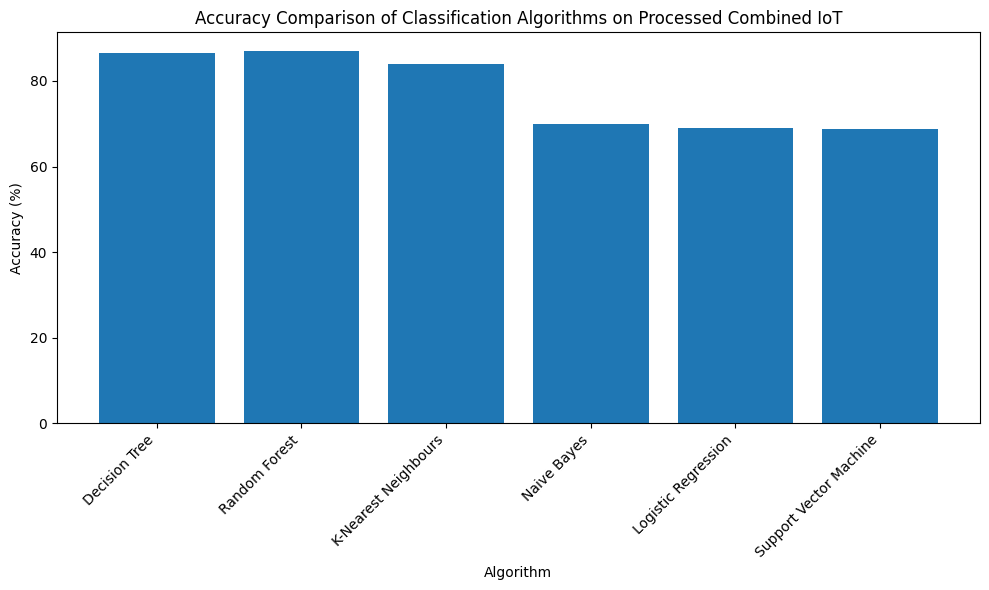

In [22]:
# Visualise and compare accuracy of different algorithms for the Processed Combined IoT dataset

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.bar(iot_summary_table["Algorithm"], iot_summary_table["Accuracy (%)"])

plt.title("Accuracy Comparison of Classification Algorithms on Processed Combined IoT")
plt.xlabel("Algorithm")
plt.ylabel("Accuracy (%)")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

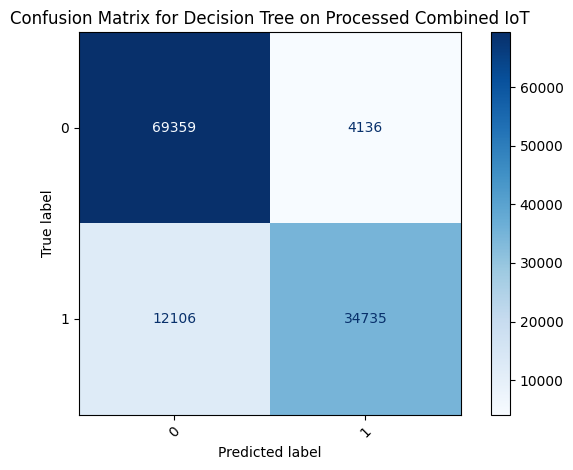

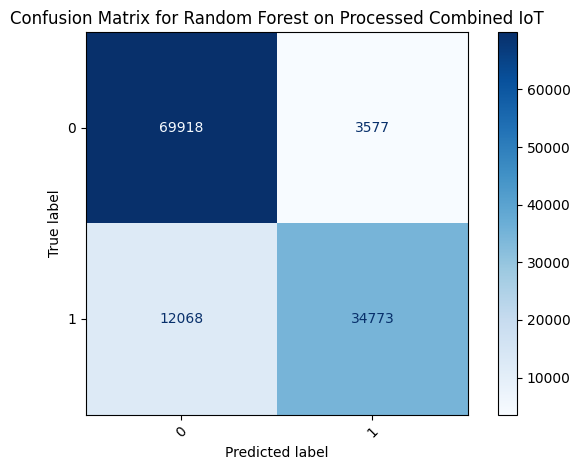

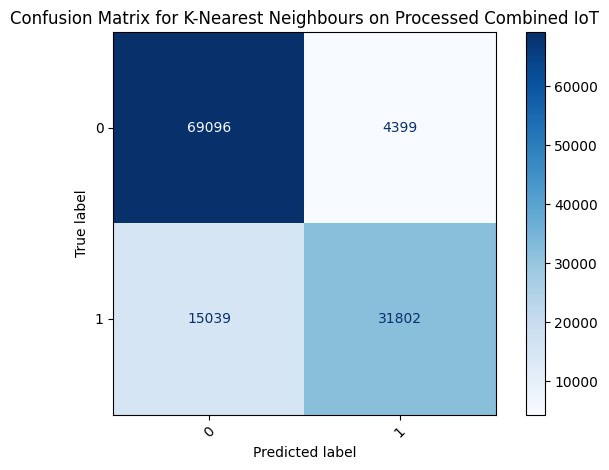

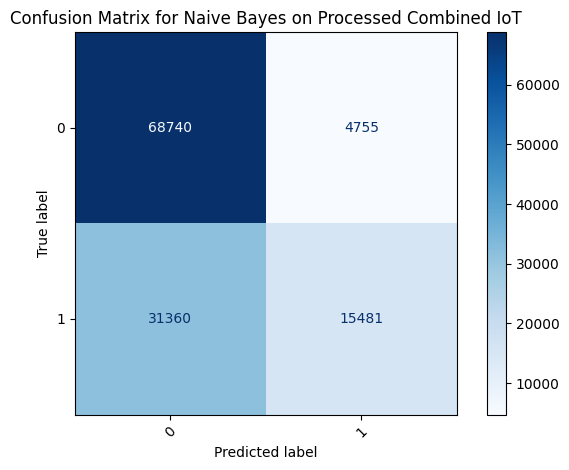

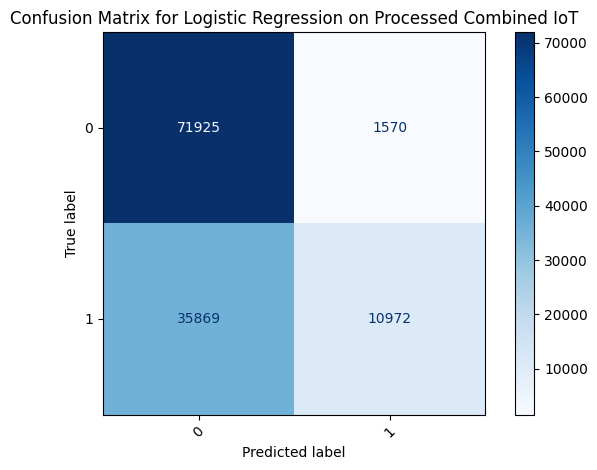

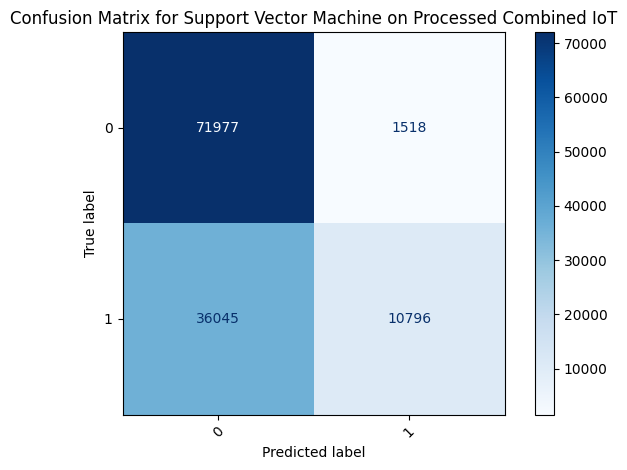

In [23]:
# Plot confusion matrices for all Processed Combined IoT algorithms

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for model_name, result in iot_all_results.items():
    cm = result["confusion_matrix"]

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=iot_class_labels
    )

    disp.plot(values_format='d', cmap='Blues')
    plt.title(f"Confusion Matrix for {model_name} on Processed Combined IoT")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()